# GoalPilot AI ML Core v0.1

# The Notebook Structure

## GoalPilot AI v0.1

Problem Statement

Step 1 : Import Libraries

Step 2 : Load Dataset

Step 3 : Data Cleaning

Step 4 : Exploratory Data Analysis (EDA)

Step 5 : Feature Engineering
- 5.0 Date Features
- 5.1 Lag Features
  - 5.1.1 Task-wise Lag
  - 5.1.2 Day-wise Lag
- 5.2 Rolling Features
- 5.3 Behavioral Features
- 5.4 Experimental GoalPilot AI Features
- 5.5 Final Feature Review & Merge

Step 6 : Data Preprocessing
- 6.1 Select Features & Target
- 6.2 Handle Missing Values
- 6.3 Train-Test Split
- 6.4 Final Preprocessed Dataset Review

Step 7 : Linear Regression
- 7.1 Build Pipeline
- 7.2 Train Model
- 7.3 Make Predictions

Step 8 : Model Evaluation
- 8.1 Evaluation Metrics
- 8.2 Actual vs Predicted
- 8.3 Residual Analysis
- 8.4 Prediction Summary

Step 9 : Random Forest
- 9.1 Build Pipeline
- 9.2 Train Model
- 9.3 Make Predictions
- 9.4 Model Evaluation
- 9.5 Model Comparison

Step 10 : Hyperparameter Tuning
- 10.1 Time Series Cross Validation
- 10.2 Randomized Search
- 10.3 Train Optimized Model
- 10.4 Make Predictions
- 10.5 Model Evaluation
- 10.6 Model Interpretation

Step 11 : XGBoost
- 11.1 Build Pipeline
- 11.2 Train Model
- 11.3 Make Predictions
- 11.4 Model Evaluation
- 11.5 Final Model Comparison

Step 12 : Model Explainability
- 12.1 Feature Coefficients

Step 13 : Future Prediction
- 13.1 Create New Input Data
- 13.2 Predict Future Study Hours
- 13.3 Prediction Summary

Step 14 : Project Limitations & Future Improvements

Step 15 : Project Conclusion

Step 16 : Model Persistence
- 16.1 Save the Trained Model
- 16.2 Verify the Saved Model

# GoalPilot AI v0.1

## AI-Powered Learning Performance Prediction & Explainability

### Problem Statement

Students record their daily learning activities, but mentors often struggle to identify learning patterns, predict future performance, and understand the reasons behind those predictions.

This project analyzes daily learning data, engineers meaningful features, builds a Machine Learning model to predict future study hours, and explains every prediction using SHAP for transparent decision-making.

---
Author : Priyal Sagar

## Step 1 : Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ==========================================
# Project Configuration
# ==========================================

RANDOM_STATE = 42
N_ESTIMATORS = 100
N_SPLITS = 5
N_ITER = 20

## Step 2 : Load Dataset

In [3]:
# mount drive to load dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:

# Define the path to the CSV file.
csv_file_path = '/content/drive/MyDrive/Tech Journey/AI ML/ML PROJECTS/GoalPilot AI/data/daily_tracker.csv'

# Load the dataset into a pandas DataFrame.
df = pd.read_csv(csv_file_path);

# Display the first 5 rows of the DataFrame.
print("First 5 rows of the dataset:")
display(df.head())

# Display a concise summary of the DataFrame.
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,Date,Domain,Subject,Topic,Task,Duration Input,Time (hrs),Status,Type,Remarks,Alert,Streak,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,31/03/2026,Misc,G sheet,G sheet setup,Daily tracker made,NaN,2.0,True,Support,still 3 more tabs pending,🔥 1 | +20 XP,1.0,NaN,NaN,NaN,NaN
1,31/03/2026,UPSC,Indian Society,Urbanization,"imp data, facts, causes, challenges",NaN,1.0,True,Support,for tomorrow :- govt initiatives and ans writi...,🔥 1 | +10 XP,1.0,NaN,NaN,NaN,NaN
2,1/4/2026,Tech,Python,Matplotlib,"Intro + pyplot basics (.plot, .show)",NaN,1.0,True,Core,understood basics and import,🔥 2 | +10 XP,2.0,NaN,NaN,NaN,NaN
3,1/4/2026,Tech,Python,Matplotlib,"Charts (bar, pie, histogram)",NaN,1.0,True,Core,NaN,🔥 2 | +10 XP,2.0,NaN,NaN,NaN,NaN
4,1/4/2026,Misc,G sheet,G sheet setup,Daily tracker modifications,NaN,1.0,True,Support,energy -> type and dashboard modification,🔥 2 | +10 XP,2.0,NaN,NaN,NaN,NaN



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            232 non-null    object 
 1   Domain          232 non-null    object 
 2   Subject         232 non-null    object 
 3   Topic           232 non-null    object 
 4   Task            231 non-null    object 
 5   Duration Input  111 non-null    object 
 6   Time (hrs)      225 non-null    float64
 7   Status          998 non-null    bool   
 8   Type            231 non-null    object 
 9   Remarks         137 non-null    object 
 10  Alert           232 non-null    object 
 11  Streak          232 non-null    float64
 12  Unnamed: 12     0 non-null      float64
 13  Unnamed: 13     11 non-null     object 
 14  Unnamed: 14     11 non-null     object 
 15  Unnamed: 15     10 non-null     object 
dtypes: bool(1), float64(3), object(12)
memory usage: 118.1+ KB


## Step 3 : Data Cleaning

The raw dataset contains empty rows and unused columns exported from Google Sheets.

In this step we:
- Remove unused columns
- Remove completely empty records
- Reset the index
- Verify the cleaned dataset

In [5]:
# Remove unnecessary 'Unnamed' columns
columns_to_remove = ['Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15']

# Filter out columns that do not exist in the DataFrame to prevent errors.
existing_columns_to_remove = [col for col in columns_to_remove if col in df.columns]

# Drop the identified columns from the DataFrame.
if existing_columns_to_remove:
    df_cleaned = df.drop(columns=existing_columns_to_remove)
else:
    df_cleaned = df.copy() # Make a copy if no columns were removed

# Remove rows where the 'Date' column is missing (NaN)
df_cleaned = df_cleaned.dropna(subset=['Date'])

# Reset the index of the DataFrame
df_cleaned = df_cleaned.reset_index(drop=True)

# Store the cleaned dataframe as df_cleaned (already done in previous steps).

# Display verification with concise output
print(f"Original Shape : {df.shape}")
print(f"Cleaned Shape  : {df_cleaned.shape}")

print("\nFirst 5 rows of the cleaned dataset:")
display(df_cleaned.head())

print("\nCleaned DataFrame Info:")
df_cleaned.info()

Original Shape : (998, 16)
Cleaned Shape  : (232, 12)

First 5 rows of the cleaned dataset:


,Date,Domain,Subject,Topic,Task,Duration Input,Time (hrs),Status,Type,Remarks,Alert,Streak
0,31/03/2026,Misc,G sheet,G sheet setup,Daily tracker made,NaN,2.0,True,Support,still 3 more tabs pending,🔥 1 | +20 XP,1.0
1,31/03/2026,UPSC,Indian Society,Urbanization,"imp data, facts, causes, challenges",NaN,1.0,True,Support,for tomorrow :- govt initiatives and ans writi...,🔥 1 | +10 XP,1.0
2,1/4/2026,Tech,Python,Matplotlib,"Intro + pyplot basics (.plot, .show)",NaN,1.0,True,Core,understood basics and import,🔥 2 | +10 XP,2.0
3,1/4/2026,Tech,Python,Matplotlib,"Charts (bar, pie, histogram)",NaN,1.0,True,Core,NaN,🔥 2 | +10 XP,2.0
4,1/4/2026,Misc,G sheet,G sheet setup,Daily tracker modifications,NaN,1.0,True,Support,energy -> type and dashboard modification,🔥 2 | +10 XP,2.0



Cleaned DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            232 non-null    object 
 1   Domain          232 non-null    object 
 2   Subject         232 non-null    object 
 3   Topic           232 non-null    object 
 4   Task            231 non-null    object 
 5   Duration Input  111 non-null    object 
 6   Time (hrs)      225 non-null    float64
 7   Status          232 non-null    bool   
 8   Type            231 non-null    object 
 9   Remarks         137 non-null    object 
 10  Alert           232 non-null    object 
 11  Streak          232 non-null    float64
dtypes: bool(1), float64(2), object(9)
memory usage: 20.3+ KB


## Step 4 : Exploratory Data Analysis (EDA)

EDA helps understand the dataset before feature engineering and model building.

In this step, we will:
- Understand numerical features
- Explore categorical features
- Study learning patterns
- Identify useful insights

In [6]:
# Identify numerical columns
numerical_cols = ['Time (hrs)', 'Streak']
num_cols = [col for col in numerical_cols if col in df_cleaned.columns]

# 1. Summary statistics for numerical columns
print("### Numerical Summary")
if num_cols:
    display(df_cleaned[num_cols].describe().T)
else:
    print("No numerical columns found for summary statistics.")

# 2. Missing values for every column
print("### Missing Values Count")
missing_values = df_cleaned.isnull().sum()
missing_values_filtered = missing_values[missing_values > 0]
if not missing_values_filtered.empty:
    display(missing_values_filtered)
else:
    print("No missing values found in any column.")

# 3. Unique values count for specific categorical columns
print("### Unique Value Counts")
for col in ['Domain', 'Subject', 'Type']:
    if col in df_cleaned.columns:
        print(f"Number of unique {col}: {df_cleaned[col].nunique()}")
    else:
        print(f"Column '{col}' not found in the DataFrame.")

# 4. Average study hours grouped by Domain
print("### Average Study Hours by Domain")
if 'Domain' in df_cleaned.columns and 'Time (hrs)' in df_cleaned.columns:
    avg_hours_by_domain = df_cleaned.groupby('Domain')['Time (hrs)'].mean().sort_values(ascending=False)
    display(avg_hours_by_domain)
else:
    print("Required columns 'Domain' or 'Time (hrs)' not found for this analysis.")

# 4. Average study hours grouped by Subject (Top 10)
print("### Average Study Hours by Subject (Top 10)")
if 'Subject' in df_cleaned.columns and 'Time (hrs)' in df_cleaned.columns:
    avg_hours_by_subject = df_cleaned.groupby('Subject')['Time (hrs)'].mean().sort_values(ascending=False).head(10)
    display(avg_hours_by_subject)
else:
    print("Required columns 'Subject' or 'Time (hrs)' not found for this analysis.")

# 5. Top 10 most studied topics
print("### Top 10 Most Studied Topics")
if 'Topic' in df_cleaned.columns:
    top_topics = df_cleaned['Topic'].value_counts().head(10)
    display(top_topics)
else:
    print("Column 'Topic' not found in the DataFrame.")

### Numerical Summary


,count,mean,std,min,25%,50%,75%,max
Time (hrs),225.0,1.636978,1.296419,0.0,0.75,1.32,2.1,7.33
Streak,232.0,11.090517,8.703161,0.0,4.00,9.00,17.0,34.00


### Missing Values Count


,0
Task,1
Duration Input,121
Time (hrs),7
Type,1
Remarks,95


### Unique Value Counts
Number of unique Domain: 3
Number of unique Subject: 33
Number of unique Type: 3
### Average Study Hours by Domain


,Time (hrs)
Domain,
Tech,2.044444
Misc,1.434286
UPSC,1.302143


### Average Study Hours by Subject (Top 10)


,Time (hrs)
Subject,
self counselling,3.000000
OLQ,2.500000
ML,2.414426
Worksheet,2.064643
python,2.040000
TEST,2.000000
help,1.750000
G sheet,1.528571
gd,1.500000


### Top 10 Most Studied Topics


,count
Topic,
worksheet,16
Matplotlib,12
kaggle intermediate ML,10
number system --> 1-26 total lectures,9
ECONOMICS WS #12,9
IR WS #11,8
KAGGLE FEATURE ENGINEERING,8
Renaissance,5
ML basics,5


### Key Findings

- **Study Time Distribution:** The average study session is around 1.6 hours, with some sessions extending significantly longer (max 7.33 hours). Streaks show an average consistency of 11 days.
- **Missing Data:** 'Duration Input' and 'Remarks' columns have a substantial number of missing values (121 and 95 respectively), while 'Time (hrs)', 'Task', and 'Type' have a few missing entries. This indicates these columns will require imputation or careful handling in feature engineering.
- **Learning Domains:** The dataset covers 3 distinct learning domains: Tech, Misc, and UPSC. The 'Tech' domain exhibits the highest average study hours.
- **Subject Variety:** There are 33 unique subjects being tracked, showing a wide range of learning topics.
- **Top Subjects/Topics:** 'Self counselling', 'OLQ', and 'ML' are subjects with higher average study hours. 'worksheet', 'Matplotlib', and 'kaggle intermediate ML' are among the most frequently studied topics, highlighting a focus on practical and machine learning-related content.

# Step 5 : Feature Engineering

Feature Engineering is the process of creating meaningful features from existing data to help Machine Learning models learn better patterns.

The objective is not to create more features, but to create features that improve prediction performance and provide meaningful insights.

In this project, Feature Engineering is divided into:

- 5.0 Date Features
- 5.1 Lag Features
    - 5.1.1 Task-wise Lag
    - 5.1.2 Day-wise Lag
- 5.2 Rolling Features
- 5.3 Behavioral Features
- 5.4 Custom GoalPilot AI Features
- 5.5 Final Feature Review

## Step 5.0 : Date Features

Dates contain valuable information that machine learning models cannot understand directly.

In this step, the Date column is converted into datetime format and new calendar-based features are extracted.

Features Created:

- Day
- Month
- Weekend

In [7]:
# Convert Date column into datetime format
df_cleaned["Date"] = pd.to_datetime(
    df_cleaned["Date"],
    dayfirst=True,
    errors="coerce"
)

# Extract Day Name
df_cleaned["Day"] = df_cleaned["Date"].dt.day_name()

# Extract Month Name
df_cleaned["Month"] = df_cleaned["Date"].dt.month_name()

# Create Weekend Flag
df_cleaned["Weekend"] = df_cleaned["Day"].isin(
    ["Saturday", "Sunday"]
)

# Preview newly created features
display(
    df_cleaned[
        ["Date", "Day", "Month", "Weekend"]
    ].head()
)

,Date,Day,Month,Weekend
0,2026-03-31,Tuesday,March,False
1,2026-03-31,Tuesday,March,False
2,2026-04-01,Wednesday,April,False
3,2026-04-01,Wednesday,April,False
4,2026-04-01,Wednesday,April,False


## Step 5.1 : Lag Features

Lag features use information from previous observations to help the model understand learning continuity.

Since GoalPilot AI records data at both **task level** and **day level**, we create two types of lag features:

- **Task-wise Lag** → Previous study task
- **Day-wise Lag** → Previous day's overall learning behaviour

This helps the model learn both immediate and long-term study patterns.

### Step 5.1.1 : Task-wise Lag Features

Task-wise lag features capture information from the immediately previous study task.

Feature Created:

- Previous Task Study Hours

In [8]:
# Sort dataset chronologically before creating lag features
df_cleaned = df_cleaned.sort_values("Date").reset_index(drop=True)

# Previous task study hours
df_cleaned["Prev_Task_Hours"] = df_cleaned["Time (hrs)"].shift(1)

# Preview
display(
    df_cleaned[
        [
            "Date",
            "Task",
            "Time (hrs)",
            "Prev_Task_Hours"
        ]
    ].head(10)
)

,Date,Task,Time (hrs),Prev_Task_Hours
0,2026-03-31,Daily tracker made,2.00,NaN
1,2026-03-31,"imp data, facts, causes, challenges",1.00,2.00
2,2026-04-01,"Intro + pyplot basics (.plot, .show)",1.00,1.00
3,2026-04-01,"Charts (bar, pie, histogram)",1.00,1.00
4,2026-04-01,Daily tracker modifications,1.00,1.00
5,2026-04-01,"data, manifestation, causes, govt (initiatives...",1.00,1.00
6,2026-04-01,"constitutional provisions, primary edu. : data...",0.33,1.00
7,2026-04-02,matplotlib plotting FUNCTIONS,1.00,0.33
8,2026-04-02,"pyplot - Charts (bar, pie, histogram)",1.00,1.00
9,2026-04-03,"scatter plot, subplots, layout adjustment, sav...",2.00,1.00


### Step 5.1.2 : Day-wise Lag Features

Task-wise lag captures information from the immediately previous task, but it cannot represent a student's overall daily learning behaviour.

To capture day-level learning continuity, the dataset is first aggregated into a daily summary table. Lag features are then created using the previous day's study behaviour.

Features Created

- Total Day Study Hours
- Daily Streak

Lag Features Created

- Previous Day Total Study Hours
- Previous Day Streak

These features help the model understand whether today's learning behaviour is improving, declining, or remaining consistent compared to the previous day.

In [9]:
# Create day-level summary table
daily_features = (
    df_cleaned
    .groupby("Date")
    .agg(
        Total_Day_Hours=("Time (hrs)", "sum"),
        Streak=("Streak", "first")
    )
    .reset_index()
)

# Previous day's total study hours
daily_features["Prev_Day_Total_Hours"] = (
    daily_features["Total_Day_Hours"].shift(1)
)

# Previous day's streak
daily_features["Prev_Day_Streak"] = (
    daily_features["Streak"].shift(1)
)

# Preview
display(
    daily_features[
        [
            "Date",
            "Total_Day_Hours",
            "Streak",
            "Prev_Day_Total_Hours",
            "Prev_Day_Streak"
        ]
    ].head(10)
)

,Date,Total_Day_Hours,Streak,Prev_Day_Total_Hours,Prev_Day_Streak
0,2026-03-31,3.00,1.0,NaN,NaN
1,2026-04-01,4.33,2.0,3.00,1.0
2,2026-04-02,2.00,3.0,4.33,2.0
3,2026-04-03,3.00,4.0,2.00,3.0
4,2026-04-04,2.00,5.0,3.00,4.0
5,2026-04-05,2.00,6.0,2.00,5.0
6,2026-04-06,4.25,7.0,2.00,6.0
7,2026-04-07,4.37,8.0,4.25,7.0
8,2026-04-08,4.36,9.0,4.37,8.0
9,2026-04-09,5.36,10.0,4.36,9.0


## Step 5.2 : Rolling Features

Rolling features summarize recent learning behaviour instead of relying on only one previous observation.

Unlike lag features, rolling features capture study trends over multiple tasks or days, helping the model identify learning consistency and short-term momentum.

Features Created:

- Rolling 3-Day Average Study Hours
- Rolling 7-Day Average Study Hours

In [10]:
# Rolling 3-day average study hours
daily_features["Rolling_3_Day_Avg"] = (
    daily_features["Total_Day_Hours"]
    .rolling(window=3, min_periods=1)
    .mean()
).round(2)

# Rolling 7-day average study hours
daily_features["Rolling_7_Day_Avg"] = (
    daily_features["Total_Day_Hours"]
    .rolling(window=7, min_periods=1)
    .mean()
).round(2)

display(
    daily_features[
        [
            "Date",
            "Total_Day_Hours",
            "Rolling_3_Day_Avg",
            "Rolling_7_Day_Avg"
        ]
    ].head(10)
)

,Date,Total_Day_Hours,Rolling_3_Day_Avg,Rolling_7_Day_Avg
0,2026-03-31,3.00,3.00,3.00
1,2026-04-01,4.33,3.66,3.66
2,2026-04-02,2.00,3.11,3.11
3,2026-04-03,3.00,3.11,3.08
4,2026-04-04,2.00,2.33,2.87
5,2026-04-05,2.00,2.33,2.72
6,2026-04-06,4.25,2.75,2.94
7,2026-04-07,4.37,3.54,3.14
8,2026-04-08,4.36,4.33,3.14
9,2026-04-09,5.36,4.70,3.62


## Step 5.3 : Behavioral Features

Previous features focused on **when** and **how much** a student studies. In this step, we focus on **how** the student learns.

Behavioral features measure the variety of subjects and topics studied, providing additional insight into a student's learning pattern.

Features engineered:

- Subject_Diversity
- Topic_Diversity

In [11]:
# Calculate the number of unique subjects and topics
# studied on each day.

daily_features["Subject_Diversity"] = (
    df_cleaned.groupby("Date")["Subject"]
    .nunique()
    .values
)

daily_features["Topic_Diversity"] = (
    df_cleaned.groupby("Date")["Topic"]
    .nunique()
    .values
)

# Preview
display(
    daily_features[
        [
            "Date",
            "Subject_Diversity",
            "Topic_Diversity"
        ]
    ].head(10)
)

,Date,Subject_Diversity,Topic_Diversity
0,2026-03-31,2,2
1,2026-04-01,4,4
2,2026-04-02,1,1
3,2026-04-03,2,2
4,2026-04-04,1,1
5,2026-04-05,1,1
6,2026-04-06,2,3
7,2026-04-07,3,7
8,2026-04-08,5,7
9,2026-04-09,5,8


## Step 5.4 : Experimental GoalPilot AI Features

The previous features were based on established feature engineering techniques. In this step, we introduce custom features designed specifically for GoalPilot AI.

These features are designed specifically for GoalPilot AI to capture learning behavior beyond traditional feature engineering.

Features engineered:

- Learning_Consistency
- Learning_Momentum
- Productivity_Score

> **Note:** These are Version 1 (v0.1) features. Their usefulness will be validated later using Feature Importance and SHAP values.

### GoalPilot Feature 1 : Learning Consistency

Learning Consistency measures how today's study hours compare with the student's recent average study hours.

A value close to **1** indicates consistent study behavior, while higher or lower values indicate deviations from the usual study pattern.

In [12]:
daily_features["Learning_Consistency"] = (
    daily_features["Total_Day_Hours"] /
    daily_features["Rolling_7_Day_Avg"]
).round(2)

display(
    daily_features[
        [
            "Date",
            "Total_Day_Hours",
            "Rolling_7_Day_Avg",
            "Learning_Consistency"
        ]
    ].head(10)
)

,Date,Total_Day_Hours,Rolling_7_Day_Avg,Learning_Consistency
0,2026-03-31,3.00,3.00,1.00
1,2026-04-01,4.33,3.66,1.18
2,2026-04-02,2.00,3.11,0.64
3,2026-04-03,3.00,3.08,0.97
4,2026-04-04,2.00,2.87,0.70
5,2026-04-05,2.00,2.72,0.74
6,2026-04-06,4.25,2.94,1.45
7,2026-04-07,4.37,3.14,1.39
8,2026-04-08,4.36,3.14,1.39
9,2026-04-09,5.36,3.62,1.48


### GoalPilot Feature 2 : Learning Momentum

Learning Momentum measures the change in study hours compared to the previous day.

A positive value indicates improvement, while a negative value suggests a decline in study effort.

In [13]:
daily_features["Learning_Momentum"] = (
    daily_features["Total_Day_Hours"] -
    daily_features["Prev_Day_Total_Hours"]
)

display(
    daily_features[
        [
            "Date",
            "Prev_Day_Total_Hours",
            "Total_Day_Hours",
            "Learning_Momentum"
        ]
    ].head(10)
)

,Date,Prev_Day_Total_Hours,Total_Day_Hours,Learning_Momentum
0,2026-03-31,NaN,3.00,NaN
1,2026-04-01,3.00,4.33,1.33
2,2026-04-02,4.33,2.00,-2.33
3,2026-04-03,2.00,3.00,1.00
4,2026-04-04,3.00,2.00,-1.00
5,2026-04-05,2.00,2.00,0.00
6,2026-04-06,2.00,4.25,2.25
7,2026-04-07,4.25,4.37,0.12
8,2026-04-08,4.37,4.36,-0.01
9,2026-04-09,4.36,5.36,1.00


### GoalPilot Feature 3 : Productivity Score

Productivity is not determined by study hours alone.

This feature combines:

- Total study hours
- Subject diversity
- Topic diversity

to estimate an overall daily productivity score.

> **Note:** This is the initial (v0.1) formula and will be validated later using Feature Importance and SHAP values.

In [14]:
# Version 0.1
# Simple weighted productivity formula.
# Will be validated later using Feature Importance and SHAP.

daily_features["Productivity_Score"] = (
    daily_features["Total_Day_Hours"] *
    (
        1
        + np.log1p(daily_features["Subject_Diversity"])
        + np.log1p(daily_features["Topic_Diversity"])
    )
).round(2)

# log1p(x) = log(1 + x)

display(
    daily_features[
        [
            "Date",
            "Total_Day_Hours",
            "Subject_Diversity",
            "Topic_Diversity",
            "Productivity_Score"
        ]
    ].head(10)
)

,Date,Total_Day_Hours,Subject_Diversity,Topic_Diversity,Productivity_Score
0,2026-03-31,3.00,2,2,9.59
1,2026-04-01,4.33,4,4,18.27
2,2026-04-02,2.00,1,1,4.77
3,2026-04-03,3.00,2,2,9.59
4,2026-04-04,2.00,1,1,4.77
5,2026-04-05,2.00,1,1,4.77
6,2026-04-06,4.25,2,3,14.81
7,2026-04-07,4.37,3,7,19.52
8,2026-04-08,4.36,5,7,21.24
9,2026-04-09,5.36,5,8,26.74


## Step 5.5 : Final Feature Review & Merge

All day-level features have been engineered in the `daily_features` table.

In this final step, these features are merged back into the original task-level dataset, creating the final dataset that will be used for model building.

In [15]:
# Remove duplicate Streak column before merging
# daily_features = daily_features.drop(columns=["Streak"])

# Merge all day-level features into the original dataset
df_final = df_cleaned.merge(
    daily_features,
    on="Date",
    how="left"
)

print(f"Final Dataset Shape: {df_final.shape}")
print(f"Total Features: {df_final.shape[1]}")

display(df_final.head())

print("\nDataset Information")
df_final.info()

Final Dataset Shape: (232, 27)
Total Features: 27


,Date,Domain,Subject,Topic,Task,Duration Input,Time (hrs),Status,Type,Remarks,...,Streak_y,Prev_Day_Total_Hours,Prev_Day_Streak,Rolling_3_Day_Avg,Rolling_7_Day_Avg,Subject_Diversity,Topic_Diversity,Learning_Consistency,Learning_Momentum,Productivity_Score
0,2026-03-31,Misc,G sheet,G sheet setup,Daily tracker made,NaN,2.0,True,Support,still 3 more tabs pending,...,1.0,NaN,NaN,3.00,3.00,2,2,1.00,NaN,9.59
1,2026-03-31,UPSC,Indian Society,Urbanization,"imp data, facts, causes, challenges",NaN,1.0,True,Support,for tomorrow :- govt initiatives and ans writi...,...,1.0,NaN,NaN,3.00,3.00,2,2,1.00,NaN,9.59
2,2026-04-01,Tech,Python,Matplotlib,"Intro + pyplot basics (.plot, .show)",NaN,1.0,True,Core,understood basics and import,...,2.0,3.0,1.0,3.66,3.66,4,4,1.18,1.33,18.27
3,2026-04-01,Tech,Python,Matplotlib,"Charts (bar, pie, histogram)",NaN,1.0,True,Core,NaN,...,2.0,3.0,1.0,3.66,3.66,4,4,1.18,1.33,18.27
4,2026-04-01,Misc,G sheet,G sheet setup,Daily tracker modifications,NaN,1.0,True,Support,energy -> type and dashboard modification,...,2.0,3.0,1.0,3.66,3.66,4,4,1.18,1.33,18.27



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  232 non-null    datetime64[ns]
 1   Domain                232 non-null    object        
 2   Subject               232 non-null    object        
 3   Topic                 232 non-null    object        
 4   Task                  231 non-null    object        
 5   Duration Input        111 non-null    object        
 6   Time (hrs)            225 non-null    float64       
 7   Status                232 non-null    bool          
 8   Type                  231 non-null    object        
 9   Remarks               137 non-null    object        
 10  Alert                 232 non-null    object        
 11  Streak_x              232 non-null    float64       
 12  Day                   232 non-null    object        
 13 

In [16]:
print("Missing values after merge:")
display(
    df_final[
        [
            "Rolling_7_Day_Avg",
            "Subject_Diversity",
            "Learning_Consistency",
            "Productivity_Score"
        ]
    ].isnull().sum()
)

Missing values after merge:


,0
Rolling_7_Day_Avg,0
Subject_Diversity,0
Learning_Consistency,0
Productivity_Score,0


In [17]:
# ML PIPELINE STARTS

# Step 6 : Data Preprocessing

Data preprocessing prepares the engineered dataset for machine learning.

In this step, we clean and transform the data into a format suitable for model training while preventing issues such as data leakage and inconsistent feature representations.

The preprocessing pipeline includes:

- Defining features (`X`) and target (`y`)
- Removing data leakage columns
- Handling missing values
- Encoding categorical features
- Splitting the data into training and testing sets

## Step 6.0 : Create Target Variable

The objective of GoalPilot AI is to predict **tomorrow's total study hours**.

To achieve this, we create a target variable by shifting the daily study hours one day forward.

This allows the model to learn from today's learning behavior and predict the next day's study hours.

Feature Created:

- Target_Study_Hours

In [18]:
# Create target variable (Next day's study hours)
daily_features["Target_Study_Hours"] = (
    daily_features["Total_Day_Hours"]
    .shift(-1)
)

# Preview
display(
    daily_features[
        [
            "Date",
            "Total_Day_Hours",
            "Target_Study_Hours"
        ]
    ].head(10)
)

,Date,Total_Day_Hours,Target_Study_Hours
0,2026-03-31,3.00,4.33
1,2026-04-01,4.33,2.00
2,2026-04-02,2.00,3.00
3,2026-04-03,3.00,2.00
4,2026-04-04,2.00,2.00
5,2026-04-05,2.00,4.25
6,2026-04-06,4.25,4.37
7,2026-04-07,4.37,4.36
8,2026-04-08,4.36,5.36
9,2026-04-09,5.36,0.00


Since the prediction target (Tomorrow's Total Study Hours) is a day-level variable, the remaining preprocessing and model-building steps will use `daily_features` as the modeling dataset. The merged `df_final` dataset is retained for future task-level extensions of GoalPilot AI.

In [19]:
daily_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  78 non-null     datetime64[ns]
 1   Total_Day_Hours       78 non-null     float64       
 2   Streak                78 non-null     float64       
 3   Prev_Day_Total_Hours  77 non-null     float64       
 4   Prev_Day_Streak       77 non-null     float64       
 5   Rolling_3_Day_Avg     78 non-null     float64       
 6   Rolling_7_Day_Avg     78 non-null     float64       
 7   Subject_Diversity     78 non-null     int64         
 8   Topic_Diversity       78 non-null     int64         
 9   Learning_Consistency  78 non-null     float64       
 10  Learning_Momentum     77 non-null     float64       
 11  Productivity_Score    78 non-null     float64       
 12  Target_Study_Hours    77 non-null     float64       
dtypes: datetime64[ns](1), 

In [20]:
daily_features.shape

(78, 13)

## Step 6.1 : Define Features (X) and Target (y)

Before training the model, we separate the input features (`X`) from the target variable (`y`).

To avoid data leakage, only features that would be available at prediction time are included in the baseline model.

> **Note:** The experimental GoalPilot AI features are retained in the dataset for future experimentation but are excluded from the baseline model because they depend on current-day information.

In [21]:
# Features selected for the baseline model
feature_columns = [
    "Prev_Day_Total_Hours",
    "Prev_Day_Streak",
    "Rolling_3_Day_Avg",
    "Rolling_7_Day_Avg",
    "Subject_Diversity",
    "Topic_Diversity"
]

# Input features
X = daily_features[feature_columns]

# Target variable
y = daily_features["Target_Study_Hours"]

# Preview
print("Feature Matrix (X)")
display(X.head())

print("Target Variable (y)")
display(y.head())

Feature Matrix (X)


,Prev_Day_Total_Hours,Prev_Day_Streak,Rolling_3_Day_Avg,Rolling_7_Day_Avg,Subject_Diversity,Topic_Diversity
0,NaN,NaN,3.00,3.00,2,2
1,3.00,1.0,3.66,3.66,4,4
2,4.33,2.0,3.11,3.11,1,1
3,2.00,3.0,3.11,3.08,2,2
4,3.00,4.0,2.33,2.87,1,1


Target Variable (y)


,Target_Study_Hours
0,4.33
1,2.00
2,3.00
3,2.00
4,2.00


## Step 6.2 : Handle Missing Values

Machine Learning models cannot be trained on missing values.

In this step, we identify and remove rows containing missing values in either the selected features or the target variable, ensuring the dataset is ready for model training.

In [22]:
# Combine selected features and target
model_data = X.copy()
model_data["Target_Study_Hours"] = y

# Remove rows with missing values
model_data = model_data.dropna().reset_index(drop=True)

# Separate features and target again
X = model_data.drop(columns=["Target_Study_Hours"])
y = model_data["Target_Study_Hours"]

# Verify
print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y.shape}")

print("\nMissing Values:")
print(model_data.isnull().sum())

Feature Matrix Shape : (76, 6)
Target Vector Shape  : (76,)

Missing Values:
Prev_Day_Total_Hours    0
Prev_Day_Streak         0
Rolling_3_Day_Avg       0
Rolling_7_Day_Avg       0
Subject_Diversity       0
Topic_Diversity         0
Target_Study_Hours      0
dtype: int64


In [23]:
# ==========================================
# Verify Final Modeling Dataset
# ==========================================

print("Final Features:")
print(list(X.columns))

print(f"\nNumber of Features : {X.shape[1]}")
print(f"Number of Samples  : {X.shape[0]}")

Final Features:
['Prev_Day_Total_Hours', 'Prev_Day_Streak', 'Rolling_3_Day_Avg', 'Rolling_7_Day_Avg', 'Subject_Diversity', 'Topic_Diversity']

Number of Features : 6
Number of Samples  : 76


## Step 6.3 : Train-Test Split

To evaluate the model fairly, the dataset is divided into training and testing sets.

Since GoalPilot AI predicts future study behavior, the chronological order of the data is preserved instead of randomly shuffling the observations.

This approach better reflects how the model will be used in real-world scenarios.

In [24]:
# Use the first 80% of the data for training
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Verify the split
print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

Training Samples : 60
Testing Samples  : 16


## Step 6.4 : Final Preprocessed Dataset Review

Before training the model, we perform a final review of the preprocessed data.

This helps verify that the training and testing datasets are correctly prepared and ready for model building.

In [25]:
print("Training Set")
print(f"X_train Shape : {X_train.shape}")
print(f"y_train Shape : {y_train.shape}")

print("\nTesting Set")
print(f"X_test Shape : {X_test.shape}")
print(f"y_test Shape : {y_test.shape}")

print("\nTraining Features")
display(X_train.head())

print("\nTarget Preview")
display(y_train.head())

Training Set
X_train Shape : (60, 6)
y_train Shape : (60,)

Testing Set
X_test Shape : (16, 6)
y_test Shape : (16,)

Training Features


,Prev_Day_Total_Hours,Prev_Day_Streak,Rolling_3_Day_Avg,Rolling_7_Day_Avg,Subject_Diversity,Topic_Diversity
0,3.00,1.0,3.66,3.66,4,4
1,4.33,2.0,3.11,3.11,1,1
2,2.00,3.0,3.11,3.08,2,2
3,3.00,4.0,2.33,2.87,1,1
4,2.00,5.0,2.33,2.72,1,1



Target Preview


,Target_Study_Hours
0,2.00
1,3.00
2,2.00
3,2.00
4,4.25


## Data Preprocessing Complete

The dataset has now been cleaned, transformed, and split into training and testing sets.

With the preprocessing pipeline complete, we are ready to build and evaluate our first machine learning model.

# Step 7 : Baseline Model

A baseline model provides a simple reference point for evaluating future models.

In this step, we build our first machine learning pipeline, train a baseline model, and generate predictions on unseen data.

## Step 7.1 : Build ML Pipeline

A Pipeline combines preprocessing and model training into a single workflow.

This keeps the code organized, prevents data leakage, and makes it easy to replace or compare different machine learning models.

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Baseline ML Pipeline
lr_pipeline = Pipeline(
    steps=[
        ("model", LinearRegression())
    ]
)

print("Linear Regression pipeline created successfully!")

Linear Regression pipeline created successfully!


## Step 7.2 : Train Baseline Model

The baseline pipeline is now trained using the training dataset.

During this step, the model learns the relationship between the selected features and the target variable, preparing it to make predictions on unseen data.

In [27]:
# Train the baseline pipeline
lr_pipeline.fit(X_train, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


## Step 7.3 : Make Predictions

After training, the model is used to predict study hours for the unseen test dataset.

These predictions will later be compared with the actual values to evaluate model performance.

In [28]:
# Predict study hours for the test set
y_pred = lr_pipeline.predict(X_test)

# Compare actual vs predicted values
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.round(2)
})

display(prediction_df.head(10))

,Actual,Predicted
0,2.00,3.85
1,4.05,3.85
2,7.50,4.04
3,7.13,4.61
4,8.49,4.99
5,8.27,5.80
6,6.15,5.87
7,4.37,5.49
8,9.37,5.54
9,7.38,6.75


# Step 8 : Model Evaluation

The baseline model has generated predictions on unseen data.

In this step, we evaluate the model using standard regression metrics and visualizations to understand its prediction performance and identify opportunities for improvement.

## Step 8.1 : Mean Absolute Error (MAE)

Mean Absolute Error (MAE) measures the average absolute difference between the actual and predicted values.

A lower MAE indicates better prediction accuracy.

In [29]:
from sklearn.metrics import mean_absolute_error

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} hours")

Mean Absolute Error (MAE): 1.94 hours


## Step 8.2 : Root Mean Squared Error (RMSE)

Root Mean Squared Error (RMSE) measures the average prediction error while giving more importance to larger errors.

A lower RMSE indicates better prediction performance.

In [30]:
from sklearn.metrics import root_mean_squared_error

# Calculate RMSE
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f} hours")

Root Mean Squared Error (RMSE): 2.29 hours


## Step 8.3 : R² Score

The $R^2$ (Coefficient of Determination) measures how well the model explains the variation in the target variable.

Its value ranges from 0 to 1, where a higher value indicates better predictive performance.

In [31]:
from sklearn.metrics import r2_score

# Calculate R² Score
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.2f}")

R² Score: 0.11


## Step 8.4 : Model Visualization

Evaluation metrics provide numerical insights, but visualizations help us understand the model's prediction behavior more clearly.

In this step, we visualize the relationship between actual and predicted values, followed by an analysis of the prediction errors (residuals).

### 8.4.1 : Actual vs Predicted

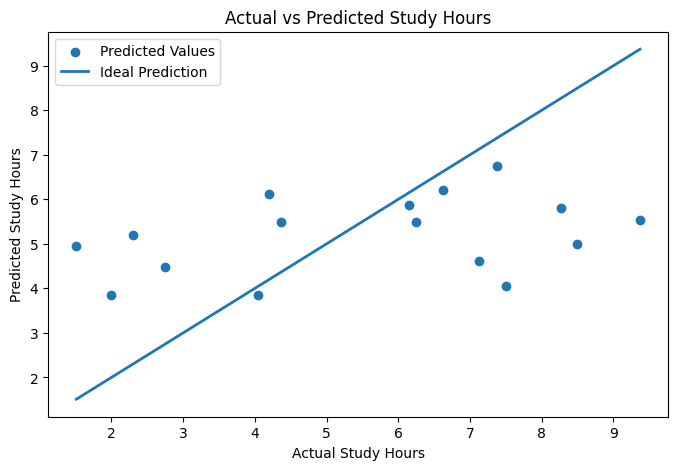

In [32]:
import matplotlib.pyplot as plt

# Create a new figure
plt.figure(figsize=(8, 5))

# Scatter plot of actual vs predicted values
plt.scatter(y_test, y_pred,label="Predicted Values")

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2,
    label="Ideal Prediction"
)

# Labels and title
plt.title("Actual vs Predicted Study Hours")
plt.xlabel("Actual Study Hours")
plt.ylabel("Predicted Study Hours")
plt.legend()

# Show the plot
plt.show()

### 8.4.2 : Residual Plot

Residuals represent the difference between the actual and predicted values.

By visualizing these residuals, we can identify whether the model makes random errors or shows systematic prediction patterns.

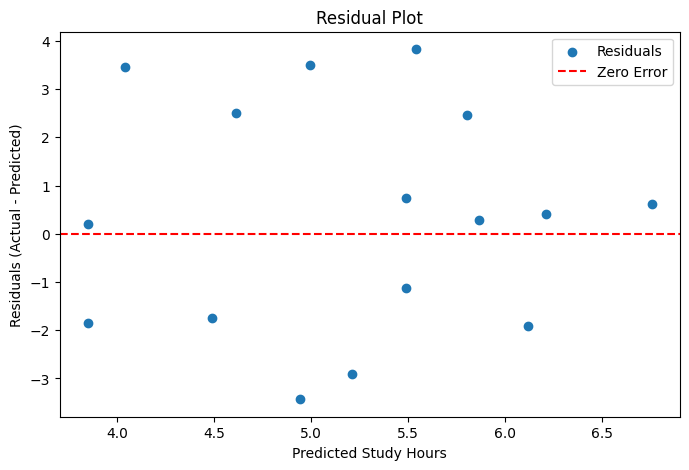

In [33]:
# Calculate residuals
residuals = y_test - y_pred

# Create a new figure
plt.figure(figsize=(8, 5))

# Scatter plot of predicted values vs residuals
plt.scatter(y_pred, residuals, label="Residuals")

# Reference line at zero error
plt.axhline(y=0, color="red", linestyle="--", label="Zero Error")

# Labels and title
plt.title("Residual Plot")
plt.xlabel("Predicted Study Hours")
plt.ylabel("Residuals (Actual - Predicted)")

# Display legend
plt.legend()

# Show the plot
plt.show()

In [34]:
residuals.min()

-3.4314433127007247

In [35]:
residuals.max()

3.828047664388345

## Step 8.5 : Model Interpretation

The baseline Linear Regression model was able to learn general learning patterns from the historical data.

However, the evaluation metrics and visualizations indicate that the model struggles to capture more complex relationships, particularly for days with higher study hours.

This baseline serves as a benchmark for comparing more advanced machine learning models in the next stages of the project.

# Step 9 : Random Forest Model

Linear Regression assumes a linear relationship between the features and the target variable.

To capture more complex and non-linear learning patterns, we now train a Random Forest model and compare its performance with the baseline model.

## Step 9.1 : Build Random Forest Pipeline

A new pipeline is created using the Random Forest Regressor.

Using the same pipeline structure makes it easy to compare different machine learning models while maintaining a consistent workflow.

In [36]:
# Import Random Forest
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest pipeline
rf_pipeline = Pipeline(
    steps=[
        (
            "model",
            RandomForestRegressor(
            n_estimators=N_ESTIMATORS,
            random_state=RANDOM_STATE
            )
        )
    ]
)

print("Random Forest pipeline created successfully!")

Random Forest pipeline created successfully!


## Step 9.2 : Train Random Forest Model

The Random Forest pipeline is trained using the training dataset.

Unlike Linear Regression, Random Forest learns multiple decision trees and combines their predictions, enabling it to capture more complex learning patterns.

In [37]:
# Train the Random Forest model
rf_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## Step 9.3 : Make Predictions

After training, the Random Forest model is used to predict study hours for the unseen test dataset.

These predictions will be compared with the baseline model to evaluate whether the advanced model improves performance.

In [38]:
# Predict study hours using Random Forest
rf_y_pred = rf_pipeline.predict(X_test)

# Compare actual and predicted values
rf_prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_y_pred.round(2)
})

display(rf_prediction_df.head(10))

,Actual,Predicted
0,2.00,4.13
1,4.05,4.64
2,7.50,3.32
3,7.13,5.54
4,8.49,3.75
5,8.27,4.33
6,6.15,4.12
7,4.37,4.72
8,9.37,5.09
9,7.38,5.38


## Step 9.4 : Evaluate Random Forest Model

The Random Forest model is evaluated using the same metrics as the baseline model.

Using identical evaluation criteria ensures a fair comparison between the two models.

### 9.4.1 : Mean Absolute Error (MAE)

In [39]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE
rf_mae = mean_absolute_error(y_test, rf_y_pred)

print(f"Random Forest MAE: {rf_mae:.2f} hours")

Random Forest MAE: 2.31 hours


### 9.4.2 : Root Mean Squared Error (RMSE)

In [40]:
from sklearn.metrics import root_mean_squared_error

# Calculate RMSE
rf_rmse = root_mean_squared_error(y_test, rf_y_pred)

print(f"Random Forest RMSE: {rf_rmse:.2f} hours")

Random Forest RMSE: 2.72 hours


### 9.4.3 : R² Score

In [41]:
from sklearn.metrics import r2_score

# Calculate R²
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"Random Forest R² Score: {rf_r2:.2f}")

Random Forest R² Score: -0.24


## Step 9.5 : Model Interpretation

The Random Forest model did not outperform the baseline Linear Regression model on the current dataset.

This is likely due to the limited number of training samples and the use of default hyperparameters.

The results highlight the importance of selecting models based on data characteristics rather than assuming that more complex models will always perform better.

The Random Forest model will be revisited after hyperparameter tuning and time-series cross-validation.

# Step 10 : Model Optimization

The baseline Random Forest model was trained using default hyperparameters.

In this step, we optimize the model using time-series cross-validation and hyperparameter tuning to improve its predictive performance.

## Step 10.1 : Time Series Cross Validation

Since GoalPilot AI predicts future study behavior, preserving the chronological order of the data is essential.

Time Series Cross Validation evaluates the model using multiple train-test splits while ensuring that future observations are never used to predict the past.

In [42]:
from sklearn.model_selection import TimeSeriesSplit

# Create Time Series Cross Validator
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print("Time Series Cross Validator created successfully!")

Time Series Cross Validator created successfully!


## Step 10.2 : Hyperparameter Tuning

The initial Random Forest model was trained using default hyperparameters.

In this step, Randomized Search is used to explore different hyperparameter combinations and identify the configuration that provides the best performance.

In [43]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter search space
param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

### Step 10.2.1 : Randomized Search

Randomized Search evaluates multiple random combinations of hyperparameters using Time Series Cross Validation.

The best-performing combination is selected to create an optimized Random Forest model.

In [44]:
# Perform Randomized Search (hyperparameter tuning algorithm)
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train Randomized Search
random_search.fit(X_train, y_train)

print("Hyperparameter tuning completed successfully!")

Hyperparameter tuning completed successfully!


### Step 10.2.2 : Best Hyperparameters

After evaluating multiple hyperparameter combinations, Randomized Search selects the configuration that achieved the best cross-validation performance.

These optimized hyperparameters will be used to train the final Random Forest model.

In [45]:
# Display the best hyperparameters
print("Best Hyperparameters:\n")

for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nBest Cross Validation Score:")
print(f"{-random_search.best_score_:.2f} MAE")

Best Hyperparameters:

model__n_estimators: 300
model__min_samples_split: 10
model__min_samples_leaf: 4
model__max_depth: 15

Best Cross Validation Score:
1.78 MAE


## Step 10.3 : Train Optimized Random Forest Model

The optimized hyperparameters obtained from Randomized Search are now used to train the final Random Forest model.

This model will be evaluated and compared with the baseline models to measure the impact of hyperparameter tuning.

In [46]:
# Retrieve the best Random Forest pipeline
best_rf_pipeline = random_search.best_estimator_

# Train the optimized model
best_rf_pipeline.fit(X_train, y_train)

print("Optimized Random Forest model trained successfully!")

Optimized Random Forest model trained successfully!


## Step 10.4 : Make Predictions

The optimized Random Forest model is used to predict study hours for the unseen test dataset.

These predictions will be compared with both the baseline Linear Regression model and the default Random Forest model.

In [47]:
# Predict using the optimized Random Forest model
best_rf_y_pred = best_rf_pipeline.predict(X_test)

# Compare actual and predicted values
best_rf_prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_rf_y_pred.round(2)
})

display(best_rf_prediction_df.head(10))

,Actual,Predicted
0,2.00,3.97
1,4.05,4.20
2,7.50,3.09
3,7.13,4.70
4,8.49,4.29
5,8.27,4.86
6,6.15,4.99
7,4.37,4.79
8,9.37,4.90
9,7.38,5.42


## Step 10.5 : Evaluate Optimized Random Forest

The optimized Random Forest model is evaluated using the same metrics as the previous models.

This allows a fair comparison between the baseline Linear Regression, the default Random Forest, and the optimized Random Forest.

### Step 10.5.1 : Evaluation Metrics

In [48]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

# Calculate evaluation metrics
best_rf_mae = mean_absolute_error(y_test, best_rf_y_pred)
best_rf_rmse = root_mean_squared_error(y_test, best_rf_y_pred)
best_rf_r2 = r2_score(y_test, best_rf_y_pred)

# Display results
print(f"Optimized Random Forest MAE : {best_rf_mae:.2f} hours")
print(f"Optimized Random Forest RMSE: {best_rf_rmse:.2f} hours")
print(f"Optimized Random Forest R²  : {best_rf_r2:.2f}")

Optimized Random Forest MAE : 2.24 hours
Optimized Random Forest RMSE: 2.63 hours
Optimized Random Forest R²  : -0.16


### Step 10.5.2 : Model Comparison

The performance of all trained models is compared using the same evaluation metrics.

This helps identify the best-performing model before moving to the next stage of the project.

In [49]:
# Compare all models
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Optimized Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae,
        best_rf_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        best_rf_rmse
    ],
    "R² Score": [
        r2,
        rf_r2,
        best_rf_r2
    ]
})

comparison_df = comparison_df.round(2)

display(comparison_df)

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.94,2.29,0.11
1,Random Forest,2.31,2.72,-0.24
2,Optimized Random Forest,2.24,2.63,-0.16


## Step 10.6 : Model Interpretation

Hyperparameter tuning improved the Random Forest model compared to its default configuration.

However, the optimized model still did not outperform the baseline Linear Regression model.

This suggests that the current dataset is relatively small and the underlying relationship between the engineered features and the target variable is adequately captured by a simpler linear model.

The next step is to evaluate XGBoost, which often performs better on structured tabular datasets while modeling more complex feature interactions.

# Step 11 : XGBoost Model

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm widely used for structured and tabular datasets.

It builds decision trees sequentially, where each new tree learns to correct the errors made by the previous trees.

In this step, we train an XGBoost model and compare its performance with the previously trained models.

## Step 11.1 : Build XGBoost Pipeline

A new pipeline is created using the XGBoost Regressor.

Using the same pipeline structure ensures a fair comparison across all machine learning models in the project.

In [50]:
from xgboost import XGBRegressor

# Create XGBoost pipeline
xgb_pipeline = Pipeline(
    steps=[
        (
            "model",
            XGBRegressor(
                n_estimators=N_ESTIMATORS,
                random_state=RANDOM_STATE,
                objective="reg:squarederror"
            )
        )
    ]
)

print("XGBoost pipeline created successfully!")

XGBoost pipeline created successfully!


## Step 11.2 : Train XGBoost Model

The XGBoost pipeline is trained using the training dataset.

During training, the model learns patterns from the historical study data by sequentially improving upon previous prediction errors.

In [51]:
# Train the XGBoost model
xgb_pipeline.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


## Step 11.3 : Make Predictions

After training, the XGBoost model predicts study hours for the unseen test dataset.

These predictions will be evaluated and compared with the previously trained models.

In [52]:
# Predict study hours using XGBoost
xgb_y_pred = xgb_pipeline.predict(X_test)

# Compare actual and predicted values
xgb_prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_y_pred.round(2)
})

display(xgb_prediction_df.head(10))

,Actual,Predicted
0,2.00,4.11
1,4.05,4.66
2,7.50,2.62
3,7.13,5.14
4,8.49,3.02
5,8.27,3.32
6,6.15,3.09
7,4.37,3.62
8,9.37,5.32
9,7.38,4.74


## Step 11.4 : Evaluate XGBoost Model

To avoid repeating the same evaluation code for every model, a reusable evaluation function is created.

This function calculates the three standard regression metrics used throughout the project:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [53]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

# Reusable evaluation function
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"MAE : {mae:.2f} hours")
    print(f"RMSE: {rmse:.2f} hours")
    print(f"R²  : {r2:.2f}")

    return mae, rmse, r2

### Step 11.4.1 : XGBoost Evaluation

In [54]:
# Evaluate XGBoost model
xgb_mae, xgb_rmse, xgb_r2 = evaluate_model(
    y_test,
    xgb_y_pred
)

MAE : 2.76 hours
RMSE: 3.21 hours
R²  : -0.73


# Step 12 : Model Explainability

Building an accurate model is important, but understanding why it makes predictions is equally valuable.

In this step, we analyze the importance of each feature to understand which factors have the greatest influence on predicting future study hours.

## Step 12.1 : Feature Coefficients

Linear Regression learns a coefficient for each feature.

These coefficients indicate how changes in each feature influence the predicted study hours while keeping the other features constant.

In [55]:
# Extract the trained Linear Regression model
lr_model = lr_pipeline.named_steps["model"]

# Create coefficient table
coefficient_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
})

# Sort by absolute importance
coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = (
    coefficient_df
    .sort_values(
        by="Absolute_Coefficient",
        ascending=False
    )
    .drop(columns="Absolute_Coefficient")
)

display(coefficient_df)

,Feature,Coefficient
3,Rolling_7_Day_Avg,0.455037
2,Rolling_3_Day_Avg,0.378735
4,Subject_Diversity,0.305271
0,Prev_Day_Total_Hours,-0.204095
5,Topic_Diversity,-0.073924
1,Prev_Day_Streak,-0.010971


# Step 13 : Future Prediction

The trained Linear Regression model is now used to predict future study hours using new unseen input data.

This demonstrates how GoalPilot AI can estimate a student's study hours for the next day based on their recent learning behavior.

## Step 13.1 : Create New Input Data

A new input sample is created using the same features that were used during model training.

This simulates a student's learning activity before predicting the next day's study hours.

In [56]:
# New student input

new_day = pd.DataFrame({
    "Prev_Day_Total_Hours": [5.5],
    "Prev_Day_Streak": [18],
    "Rolling_3_Day_Avg": [5.2],
    "Rolling_7_Day_Avg": [4.9],
    "Subject_Diversity": [3],
    "Topic_Diversity": [5]
})

display(new_day)

,Prev_Day_Total_Hours,Prev_Day_Streak,Rolling_3_Day_Avg,Rolling_7_Day_Avg,Subject_Diversity,Topic_Diversity
0,5.5,18,5.2,4.9,3,5


## Step 13.2 : Predict Future Study Hours

The trained Linear Regression model is used to predict the next day's study hours based on the new input data.

This simulates how GoalPilot AI would generate predictions for a student's future learning activity.

In [57]:
# Predict future study hours
predicted_hours = lr_pipeline.predict(new_day)

print(
    f"Predicted Study Hours for Tomorrow: "
    f"{predicted_hours[0]:.2f} hours"
)

Predicted Study Hours for Tomorrow: 4.77 hours


## Step 13.3 : Prediction Summary

The trained Linear Regression model predicted approximately **4.77 hours** of study for the next day based on the provided learning behavior.

This demonstrates how GoalPilot AI can assist mentors and students by estimating future study effort using historical learning patterns.

# Step 14 : Project Limitations & Future Improvements

Every machine learning model has limitations. Understanding these limitations helps identify opportunities for future improvements.

This section summarizes the current limitations of GoalPilot AI v0.1 and outlines possible enhancements for future versions.

## Step 14.1 : Project Limitations

Current limitations:

- The model is trained on a relatively small dataset (76 daily records).
- Predictions are based only on historical study patterns.
- Additional behavioral and contextual features may improve performance.
- Advanced models such as Random Forest and XGBoost may perform better with larger datasets.

## Step 14.2 : Future Improvements

Future versions of GoalPilot AI can include:

- Automatic data collection from Google Sheets.
- Real-time predictions through a web application.
- Periodic model retraining using newly collected data.
- Personalized study recommendations in addition to study hour prediction.
- Enhanced feature engineering using richer learning behavior data.

# Step 15 : Project Conclusion

GoalPilot AI v0.1 successfully demonstrates an end-to-end Machine Learning workflow for predicting future study hours.

The project covers data preprocessing, feature engineering, model building, evaluation, hyperparameter tuning, explainability, and future prediction using real learning behavior data.

Among all evaluated models, Linear Regression achieved the best performance on the current dataset, making it the selected baseline model for GoalPilot AI v0.1.

As more learning data becomes available, the model can be retrained and re-evaluated to further improve prediction performance.

# Step 16 : Save the Trained Model

The final trained model is saved so that it can be loaded later without retraining.

This enables GoalPilot AI to generate predictions in future applications such as web apps, APIs, or dashboards.

In [58]:
import joblib

# Save the trained model
joblib.dump(
    lr_pipeline,
    "goalpilot_model.pkl"
)

print("Model saved successfully as 'goalpilot_model.pkl'")

Model saved successfully as 'goalpilot_model.pkl'


## Step 16.1 : Load the Saved Model

The saved model can be loaded at any time to make predictions without repeating the training process.

In [59]:
# Load the saved model
loaded_model = joblib.load("goalpilot_model.pkl")

print("Saved model loaded successfully!")

Saved model loaded successfully!


## Step 16.2 : Verify the Saved Model

The loaded model is used to predict study hours for the same sample input.

Matching predictions confirm that the model was saved and loaded correctly.


In [60]:
# Predict using the loaded model
loaded_prediction = loaded_model.predict(new_day)

print(
    f"Predicted Study Hours: "
    f"{loaded_prediction[0]:.2f} hours"
)

Predicted Study Hours: 4.77 hours
